In [2]:
# test loading video

import numpy as np
import cv2

# 加载视频文件
video_path = "../../videos/single_test/s-90-2.MP4"
cap = cv2.VideoCapture(video_path)

# 检查视频是否成功打开
if not cap.isOpened():
    print("Error opening video file.")
    exit()

# 遍历每一帧
while True:
    # 读取一帧
    ret, frame = cap.read()

    # 如果读取到帧，则进行处理
    if ret:
        # 显示帧
        cv2.imshow('Frame', frame)

        # 按下 'q' 键退出
        if cv2.waitKey(25) & 0xFF == ord('q'):
            break
        elif cv2.waitKey(25) & 0xFF == ord('s'):
            cv2.imwrite("frame.jpg", frame)
    else:
        # 视频结束，退出循环
        break

# 释放资源
cap.release()
cv2.destroyAllWindows()

In [15]:
# find hsv threshold

import cv2
import numpy as np

def nothing(x):
    pass

# 创建滑块窗口
cv2.namedWindow('HSV Thresholding')
cv2.createTrackbar('H_min', 'HSV Thresholding', 0, 180, nothing)
cv2.createTrackbar('S_min', 'HSV Thresholding', 0, 255, nothing)
cv2.createTrackbar('V_min', 'HSV Thresholding', 0, 255, nothing)
cv2.createTrackbar('H_max', 'HSV Thresholding', 180, 180, nothing)
cv2.createTrackbar('S_max', 'HSV Thresholding', 255, 255, nothing)
cv2.createTrackbar('V_max', 'HSV Thresholding', 255, 255, nothing)

# 加载图片
image_path = 'frame.jpg'  # 替换为你的图片路径
img = cv2.imread(image_path)

# 检查图片是否成功加载
if img is None:
    print("Error loading image.")
    exit()

# 缩小图像
img = cv2.resize(img, (img.shape[1] // 2, img.shape[0] // 2))

# 将 BGR 转换为 HSV
hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

while True:
    # 获取滑块的值
    h_min = cv2.getTrackbarPos('H_min', 'HSV Thresholding')
    s_min = cv2.getTrackbarPos('S_min', 'HSV Thresholding')
    v_min = cv2.getTrackbarPos('V_min', 'HSV Thresholding')
    h_max = cv2.getTrackbarPos('H_max', 'HSV Thresholding')
    s_max = cv2.getTrackbarPos('S_max', 'HSV Thresholding')
    v_max = cv2.getTrackbarPos('V_max', 'HSV Thresholding')

    # 定义 HSV 阈值
    lower_hsv = np.array([h_min, s_min, v_min])
    upper_hsv = np.array([h_max, s_max, v_max])

    # 创建 HSV 掩膜
    mask = cv2.inRange(hsv_img, lower_hsv, upper_hsv)

    # 使用掩膜提取目标区域
    result = cv2.bitwise_and(img, img, mask=mask)

    # --- 将三张图排列成 2x2 的形式 ---
    empty_img = np.zeros_like(img)
    mask = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)

    left_img = np.concatenate((img, result), axis=0)
    right_img = np.concatenate((mask, empty_img), axis=0)
    final_img = np.concatenate((left_img, right_img), axis=1)

    # 在单独的窗口中显示图像
    cv2.imshow('Image', final_img)

    # 按下 'q' 键退出
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cv2.destroyAllWindows()

In [5]:
# function to draw mask

import numpy as np
import cv2

def draw_mask(img):
    
    # 定义 HSV 阈值
    lower_hsv = np.array([77,35,63])  # 例如：选择色调在 20-30 之间，饱和度在 50-255 之间，亮度在 50-255 之间的像素
    upper_hsv = np.array([87,193,255])  # 注意：HSV 中的色调范围是 0-180，饱和度和亮度范围是 0-255
    # 创建 HSV 掩膜
    hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv_img, lower_hsv, upper_hsv)

    # # 使用掩膜提取目标区域
    # result = cv2.bitwise_and(img, img, mask=mask)

    # 查找轮廓
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # 找到最大面积轮廓
    max_area = 0
    max_contour_index = 0
    for i, contour in enumerate(contours):
        area = cv2.contourArea(contour)
        if area > max_area:
            max_area = area
            max_contour_index = i

    # 创建只包含最大面积轮廓的新掩膜
    new_mask = np.zeros_like(mask)
    cv2.drawContours(new_mask, contours, max_contour_index, (255, 255, 255), -1)

    # 使用新掩膜提取目标区域
    result = cv2.bitwise_and(img, img, mask=new_mask)
    mask = new_mask

    # --- 将三张图排列成 2x2 的形式 ---
    # 创建一个空的图像，用于填充右下角
    empty_img = np.zeros_like(img)
    # 调整 mask 图像的通道数，使其与其他图像一致
    mask = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
    # 垂直拼接第一列：原图和结果图
    left_img = np.concatenate((img, result), axis=0)
    # 垂直拼接第二列：掩膜和空图像
    right_img = np.concatenate((mask, empty_img), axis=0)
    # 水平拼接两列
    final_img = np.concatenate((left_img, right_img), axis=1)
    # 调整最终输出图像的大小（可选）
    final_img = cv2.resize(final_img, (final_img.shape[1] // 2, final_img.shape[0] // 2))
    
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
    
    return final_img, mask, result


In [51]:
# program to test video mask

import numpy as np
import cv2

# 加载视频文件
video_path = "../../videos/single_test/s-90-1.MP4"
cap = cv2.VideoCapture(video_path)

# 检查视频是否成功打开
if not cap.isOpened():
    print("Error opening video file.")
    exit()

# 遍历每一帧
while True:
    # 读取一帧
    ret, frame = cap.read()

    # 如果读取到帧，则进行处理
    if ret:
        # 显示帧
        final_img, _, _ = draw_mask(frame)
        cv2.imshow('Frame', final_img)
        # cv2.imshow('Frame', frame)

        # 按下 'q' 键退出
        if cv2.waitKey(25) & 0xFF == ord('q'):
            break
        elif cv2.waitKey(25) & 0xFF == ord('s'):
            cv2.imwrite("frame.jpg", frame)
    else:
        # 视频结束，退出循环
        break

# 释放资源
cap.release()
cv2.destroyAllWindows()

In [28]:
# calculate gradient

img = cv2.imread('frame.jpg')
final_img, mask, result = draw_mask(img)

# 2. 计算梯度
grad_x = cv2.Sobel(mask, cv2.CV_64F, 1, 0, ksize=3)
grad_y = cv2.Sobel(mask, cv2.CV_64F, 0, 1, ksize=3)

# 计算梯度幅值和方向 (可选)
grad_magnitude = np.sqrt(grad_x**2 + grad_y**2)
grad_direction = np.arctan2(grad_y, grad_x)

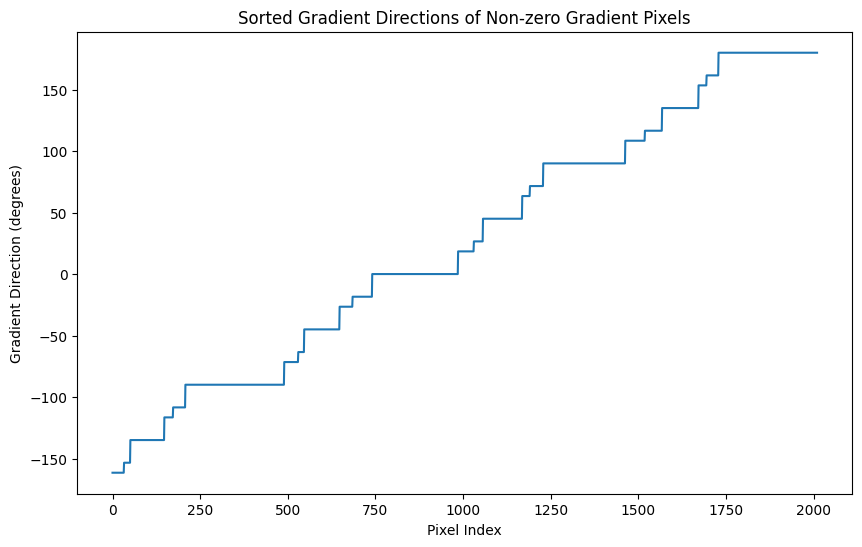

In [31]:
# visualize gradient

import matplotlib.pyplot as plt

# --- 统计非零梯度方向 ---
# 1. 找到梯度非零的像素的索引
nonzero_indices = np.where(grad_magnitude > 0)

# 2. 获取非零梯度方向
nonzero_grad_directions = grad_direction[nonzero_indices]

# 3. 将弧度制转换为角度制
nonzero_grad_directions_deg = np.degrees(nonzero_grad_directions)

# 4. 对角度值进行排序
sorted_grad_directions_deg = np.sort(nonzero_grad_directions_deg)

# --- 绘制图像 ---
plt.figure(figsize=(10, 6))  # 设置图像大小
plt.plot(sorted_grad_directions_deg)  # 绘制折线图
plt.xlabel('Pixel Index')  # 设置 x 轴标签
plt.ylabel('Gradient Direction (degrees)')  # 设置 y 轴标签
plt.title('Sorted Gradient Directions of Non-zero Gradient Pixels')  # 设置图像标题
plt.show()  # 显示图像

In [6]:
# calculate max projection length

def get_max_projection_length(mask, angle_step=1):
    """
    计算 mask 在不同旋转角度下的最大投影长度及其角度.

    Args:
        mask: 输入的二值掩膜.
        angle_step: 旋转角度步长，单位为度.

    Returns:
        max_length: 最大投影长度.
        max_angle: 最大投影长度对应的角度.
    """

    rows, cols = mask.shape[:2]
    center = (cols // 2, rows // 2)
    max_length = 0
    max_angle = 0

    for a in range(0, int(180/angle_step)):
        angle = a * angle_step
        # 1. 旋转 mask 图像
        rotation_matrix = cv2.getRotationMatrix2D(center, -angle, 1)
        rotated_mask = cv2.warpAffine(mask, rotation_matrix, (cols, rows))

        # 2. 投影
        projection = np.sum(rotated_mask, axis=0) > 0

        # 3. 计算线段长度
        length = 0
        max_line_length = 0
        for pixel in projection:
            if pixel:  
                length += 1
            else:
                max_line_length = max(length, max_line_length)
                length = 0

        # 4. 寻找最大长度
        if max_line_length > max_length:
            max_length = max_line_length
            max_angle = -angle

    return max_length, max_angle

# 计算最大投影长度和角度
img = cv2.imread('frame.jpg')
final_img, mask, result = draw_mask(img)

max_length, max_angle = get_max_projection_length(mask)
print(f"最大投影长度: {max_length}, 角度: {max_angle}")

# --- 绘制最大投影方向的直线 ---
rows, cols = img.shape[:2]  # 注意这里使用 img.shape，而不是 mask.shape
center = (cols // 2, rows // 2)

# 计算直线的起点和终点坐标
line_length = max(rows, cols)  # 设置直线长度，确保其能够跨越整个图像
x1 = int(center[0] - line_length * np.cos(np.radians(max_angle)))
y1 = int(center[1] - line_length * np.sin(np.radians(max_angle)))
x2 = int(center[0] + line_length * np.cos(np.radians(max_angle)))
y2 = int(center[1] + line_length * np.sin(np.radians(max_angle)))

# 在原始图像上绘制直线
cv2.line(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

# 显示结果
cv2.imshow("Image with Max Projection Line", img)
cv2.waitKey(0)
cv2.destroyAllWindows()

最大投影长度: 276, 角度: -45


In [7]:
def draw_line(img, angle):
    rows, cols = img.shape[:2]  # 注意这里使用 img.shape，而不是 mask.shape
    center = (cols // 2, rows // 2)

    # 计算直线的起点和终点坐标
    line_length = max(rows, cols)  # 设置直线长度，确保其能够跨越整个图像
    x1 = int(center[0] - line_length * np.cos(np.radians(angle)))
    y1 = int(center[1] - line_length * np.sin(np.radians(angle)))
    x2 = int(center[0] + line_length * np.cos(np.radians(angle)))
    y2 = int(center[1] + line_length * np.sin(np.radians(angle)))

    # 在原始图像上绘制直线
    cv2.line(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
    
    return img

In [11]:
# program to find projection direction

import numpy as np
import cv2

# 加载视频文件
video_path = "../../videos/single_test/s-90-3.MP4"
cap = cv2.VideoCapture(video_path)

# 检查视频是否成功打开
if not cap.isOpened():
    print("Error opening video file.")
    exit()

angle_list = []
length_list = []
i = 0

# 遍历每一帧
while True:
    # 读取一帧
    ret, frame = cap.read()

    # 如果读取到帧，则进行处理
    if ret:
        # 显示帧
        final_img, mask, result = draw_mask(frame)
        max_length, max_angle = get_max_projection_length(mask, angle_step=0.5)
        if max_angle < -90:
            max_angle += 180
        angle_list.append(-max_angle)
        length_list.append(max_length)
        final_img = draw_line(frame, max_angle)
        cv2.imshow('Frame', final_img)

        # 按下 'q' 键退出
        if cv2.waitKey(25) & 0xFF == ord('q'):
            break
        elif cv2.waitKey(25) & 0xFF == ord('s'):
            cv2.imwrite("frame.jpg", frame)
    else:
        # 视频结束，退出循环
        break

# 释放资源
cap.release()
cv2.destroyAllWindows()

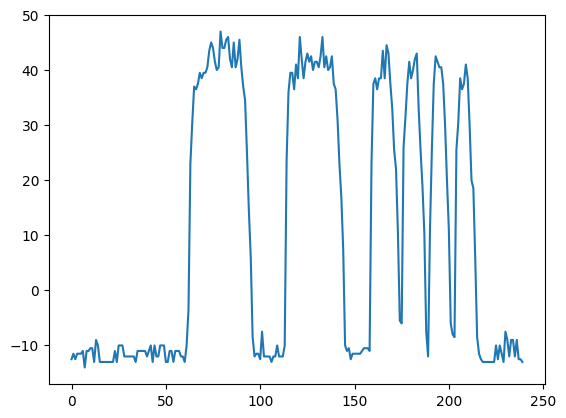

In [12]:
import matplotlib.pyplot as plt
plt.plot(angle_list)

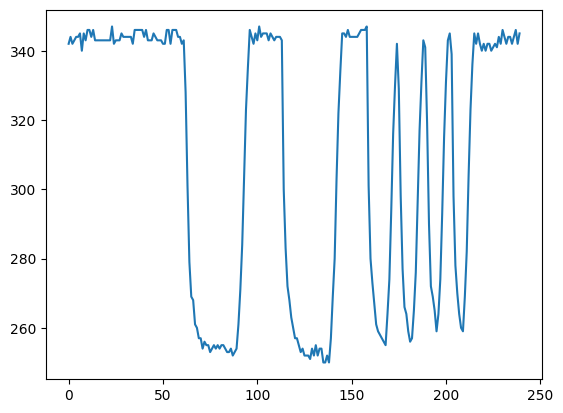

In [13]:
plt.plot(length_list)